In [12]:
import pandas as pd

# Teams
teams_original = pd.read_csv('data/teams.csv')

# Coaches
coaches_original = pd.read_csv('data/coaches.csv')

# Player for each team
players_for_team_original = pd.read_csv('data/players_teams.csv')

# Players in General
players_original = pd.read_csv('data/players.csv')

# Series Post
series_post_original = pd.read_csv('data/series_post.csv')

# Teams Post
teams_post_original = pd.read_csv('data/teams_post.csv')

# Teams in General
teams_original = pd.read_csv('data/teams.csv')

# Final one dataframe to be used!
final = pd.DataFrame()

print(players_for_team_original.head())

     playerID  year  stint tmID  lgID  GP  GS  minutes  points  oRebounds  \
0  abrossv01w     2      0  MIN  WNBA  26  23      846     343         43   
1  abrossv01w     3      0  MIN  WNBA  27  27      805     314         45   
2  abrossv01w     4      0  MIN  WNBA  30  25      792     318         44   
3  abrossv01w     5      0  MIN  WNBA  22  11      462     146         17   
4  abrossv01w     6      0  MIN  WNBA  31  31      777     304         29   

    ...    PostBlocks  PostTurnovers  PostPF  PostfgAttempted  PostfgMade  \
0   ...             0              0       0                0           0   
1   ...             0              0       0                0           0   
2   ...             1              8       8               22           6   
3   ...             2              3       7               23           8   
4   ...             0              0       0                0           0   

   PostftAttempted  PostftMade  PostthreeAttempted  PostthreeMade  PostDQ 

In [13]:
teams = teams_original.copy()

#Start by just associate team with playoff access in year 2

#Sort by each team and ascending year
teams = teams.sort_values(['franchID','year'])
#Associate playoff access in next year to previous year stats
teams['playoffNextYear'] = teams['playoff'].shift(-1)
#Remove playoff access info for last line of each team, as next line (that got shifted up) belongs to another team
teams.loc[teams['franchID'] != teams['franchID'].shift(-1),'playoffNextYear'] = None

In [14]:
#Define features and label
features = ['rank']
label = 'playoffNextYear'

#Train data -> 5 first seasons (since the beggining of this dataset)
train_data = teams[teams['year']<=5].dropna(subset=[label])
#Test data -> 6 and 7 seasons
test_data = teams[teams['year'].isin([6,7])].dropna(subset=[label])

print(train_data[features].head())
print(test_data[features].head())
print(train_data[label].head())
print(test_data[label].head())

x_train, y_train = train_data[features], train_data[label]
x_test, y_test = test_data[features], test_data[label]

   rank
2     8
3     4
4     2
5     2
6     5
    rank
7      6
9      7
19     1
20     1
29     4
2    Y
3    Y
4    Y
5    N
6    N
Name: playoffNextYear, dtype: object
7     N
9     N
19    Y
20    Y
29    Y
Name: playoffNextYear, dtype: object


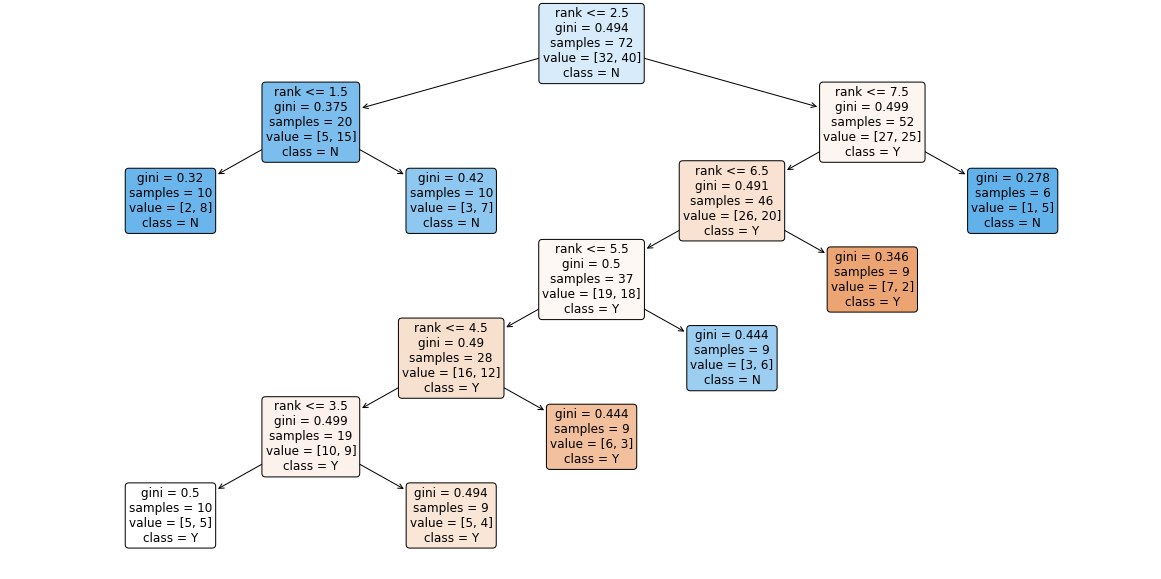

In [15]:
# Import necessary libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier()

# Train the model
clf.fit(x_train, y_train)

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=features, class_names=train_data[label].unique(), rounded=True, fontsize=12)
plt.show()

In [16]:
# Predict on the test data
y_pred = clf.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Print a detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 57.69%
              precision    recall  f1-score   support

           N       0.47      0.70      0.56        10
           Y       0.73      0.50      0.59        16

    accuracy                           0.58        26
   macro avg       0.60      0.60      0.58        26
weighted avg       0.63      0.58      0.58        26

